# Notebook 1: Exploratory Data Analysis
**Steam Sales Prediction — CIS 5450 Final Project**

Goals of this notebook
─────────────────────
1. Understand the raw data before any modelling
2. Characterise the target variable `copiesSold` (distribution, skew)
3. Explore key predictors (price, genre, publisher class, review score)
4. Surface data quality issues that inform preprocessing decisions
5. Identify potential leakage risks

## 0. Setup

In [4]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))   # project root on path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from configs.config import RAW_MERGED_PATH, RAW_GAMELIST_PATH
from src.data.loader import load_merged, load_gamelist

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:,.2f}".format)

## 1. Load raw data

In [5]:
df_raw = load_merged(RAW_MERGED_PATH, verbose=True)
df_raw.head(3)


  games_merged.csv
  Rows: 115,289   Columns: 47

  Columns with >10% nulls:
    Movies                              100.0%
    Score rank                          100.0%
    Metacritic url                      96.4%
    Reviews                             89.6%
    Notes                               79.9%
    Website                             57.6%
    Support url                         53.5%
    Tags                                29.8%
    Support email                       12.0%



,AppID,Name,copiesSold,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies,unreleased,firstReleaseDate,earlyAccess,reviewScore,publisherClass,steamUrl
0,1635980,Kubinashi Recollection,"2,637.00","Dec 8, 2021",0 - 20000,0,0,11.99,0,1,"In order to retrieve the lost memories, Sekiba...","['Simplified Chinese', 'Japanese', 'English']",[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,https://phoenixx.ne.jp/contactus/,support@phoenixx.ne.jp,True,False,False,0,NaN,0,163,8,NaN,40,158,NaN,0,0,0,0,給食頭蛮,Phoenixx Inc.,"Single-player,Steam Achievements,Steam Trading...","Action,Indie","Action,Puzzle,Faith,Cute,Pixel Graphics,Fantas...",https://shared.akamai.steamstatic.com/store_it...,NaN,False,2021-12-08T05:00:00.000Z,False,95.00,Indie,https://store.steampowered.com/app/1635980
1,3337970,Coffee Beans,36.00,"Nov 22, 2024",0 - 20000,0,0,0.69,0,0,Coffee Beans A fun and challenging Match 3 Typ...,['English'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,http://store.steampowered.com/search/?publishe...,http://store.steampowered.com/search/?publishe...,archor@archor.com,True,False,False,0,NaN,0,1,1,NaN,0,0,NaN,0,0,0,0,Archor Wright,Archor Games,"Single-player,Family Sharing","Casual,Indie","Casual,Puzzle,Clicker,2D,Capitalism,Physics,In...",https://shared.akamai.steamstatic.com/store_it...,NaN,False,2024-11-22T00:00:00.000Z,False,50.00,Indie,https://store.steampowered.com/app/3337970
2,1470270,Powerboat VR,741.00,"Dec 29, 2020",0 - 20000,0,0,18.99,0,0,Please note that this is an EARLY ACCESS game ...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,http://www.jimmyarcade.co.uk,NaN,support@jimmyarcade.co.uk,True,False,False,0,NaN,0,16,6,NaN,0,0,NaN,0,0,0,0,Jimmy Arcade Limited,Jimmy Arcade Limited,"Single-player,Tracked Controller Support,VR Su...","Indie,Simulation,Early Access","Exploration,Driving,Naval,Transportation,Manag...",https://shared.akamai.steamstatic.com/store_it...,NaN,False,2020-12-29T05:00:00.000Z,True,74.00,Indie,https://store.steampowered.com/app/1470270


In [6]:
# High-level null summary
null_pct = df_raw.isnull().mean().mul(100).sort_values(ascending=False)
null_pct[null_pct > 0]

Movies             100.00
Score rank          99.97
Metacritic url      96.43
Reviews             89.56
Notes               79.87
Website             57.56
Support url         53.52
Tags                29.76
Support email       11.97
Publishers           0.53
About the game       0.16
Developers           0.15
Genres               0.10
unreleased           0.09
firstReleaseDate     0.09
earlyAccess          0.09
reviewScore          0.09
publisherClass       0.09
copiesSold           0.09
steamUrl             0.09
Header image         0.05
Screenshots          0.05
Categories           0.01
Name                 0.00
dtype: float64

## 2. Target variable: `copiesSold`

In [7]:
# Basic stats
df_raw["copiesSold"].describe()

count       115,191.00
mean         70,582.21
std       1,549,270.46
min               0.00
25%              84.00
50%             601.00
75%           4,021.00
max     343,456,914.00
Name: copiesSold, dtype: float64

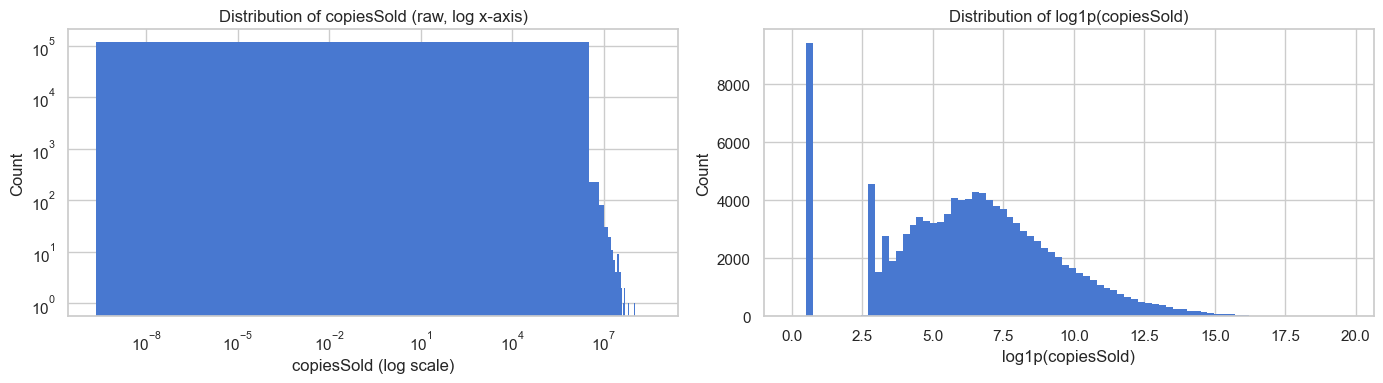

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw distribution (log x-axis)
axes[0].hist(df_raw["copiesSold"].dropna(), bins=100, log=True, edgecolor="none")
axes[0].set_xscale("log")
axes[0].set_xlabel("copiesSold (log scale)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of copiesSold (raw, log x-axis)")

# Log1p distribution
log_cs = np.log1p(df_raw["copiesSold"].dropna())
axes[1].hist(log_cs, bins=80, edgecolor="none")
axes[1].set_xlabel("log1p(copiesSold)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of log1p(copiesSold)")

plt.tight_layout()
plt.savefig("../outputs/eda_target_dist.png", dpi=150)
plt.show()

In [10]:
# Percentile table
pcts = [50, 75, 90, 95, 99, 99.5]
for p in pcts:
    val = df_raw["copiesSold"].quantile(p / 100)
    print(f"  {p:5.1f}th percentile: {val:>15,.0f} copies")

   50.0th percentile:             601 copies
   75.0th percentile:           4,021 copies
   90.0th percentile:          29,187 copies
   95.0th percentile:         101,890 copies
   99.0th percentile:       1,096,246 copies
   99.5th percentile:       2,384,454 copies


## 3. Publisher class

publisherClass
Hobbyist    64248
Indie       46369
AA           3263
AAA          1311
Name: count, dtype: int64


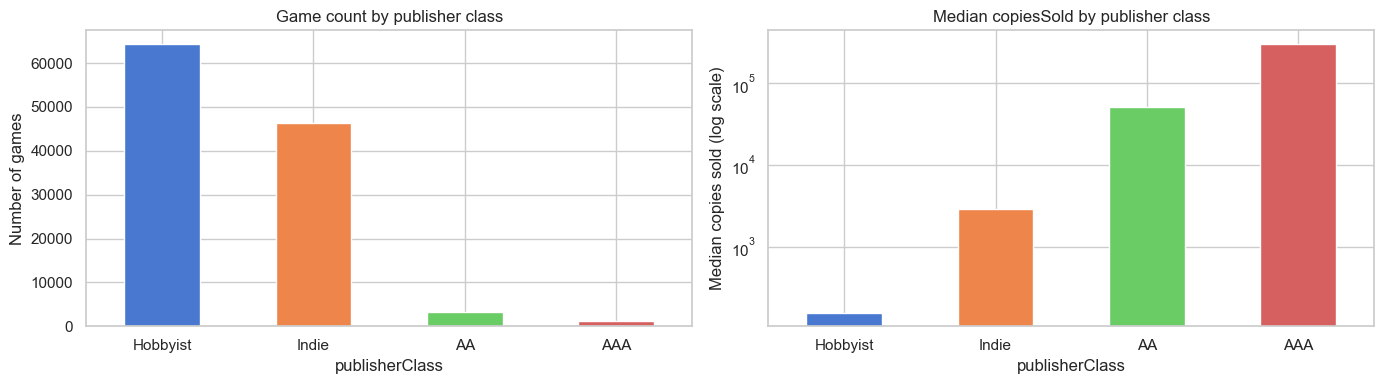

In [11]:
pub_class = df_raw["publisherClass"].value_counts()
print(pub_class)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pub_class.plot(kind="bar", ax=axes[0], color=sns.color_palette())
axes[0].set_title("Game count by publisher class")
axes[0].set_ylabel("Number of games")
axes[0].tick_params(axis="x", rotation=0)

# Median copiesSold per publisher class
median_sales = (
    df_raw.groupby("publisherClass")["copiesSold"]
    .median()
    .reindex(["Hobbyist", "Indie", "AA", "AAA"])
)
median_sales.plot(kind="bar", ax=axes[1], color=sns.color_palette())
axes[1].set_yscale("log")
axes[1].set_title("Median copiesSold by publisher class")
axes[1].set_ylabel("Median copies sold (log scale)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("../outputs/eda_publisher_class.png", dpi=150)
plt.show()

## 4. Price distribution and free-to-play

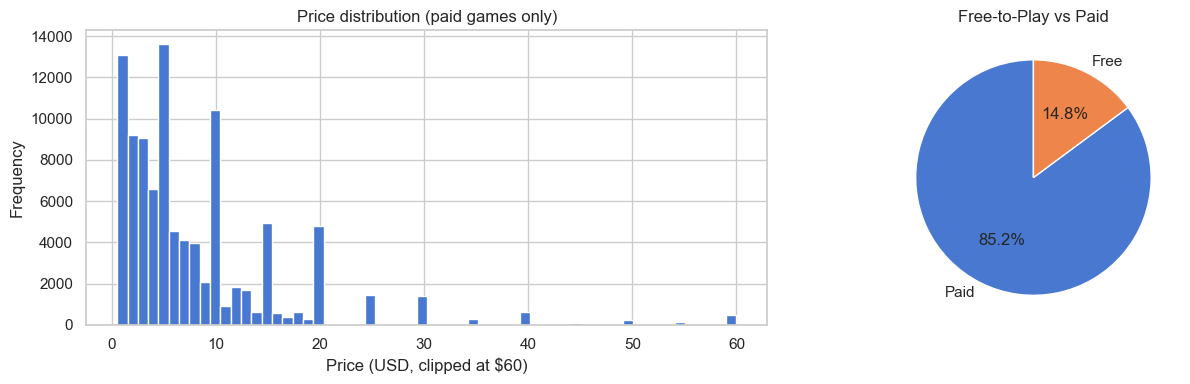

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

paid = df_raw[df_raw["Price"] > 0]
paid["Price"].clip(upper=60).plot(kind="hist", bins=60, ax=axes[0])
axes[0].set_xlabel("Price (USD, clipped at $60)")
axes[0].set_title("Price distribution (paid games only)")

ftp_counts = df_raw["Price"].eq(0).value_counts().rename({True: "Free", False: "Paid"})
ftp_counts.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=90)
axes[1].set_ylabel("")
axes[1].set_title("Free-to-Play vs Paid")

plt.tight_layout()
plt.savefig("../outputs/eda_price.png", dpi=150)
plt.show()

In [13]:
# Median sales: free vs paid
for label, mask in [("Free (Price=0)", df_raw["Price"] == 0),
                     ("Paid (Price>0)", df_raw["Price"] > 0)]:
    med = df_raw.loc[mask, "copiesSold"].median()
    n   = mask.sum()
    print(f"{label:25s}  n={n:6,d}  median copies={med:>10,.0f}")

Free (Price=0)             n=17,119  median copies=     2,314
Paid (Price>0)             n=98,170  median copies=       412


## 5. Genres

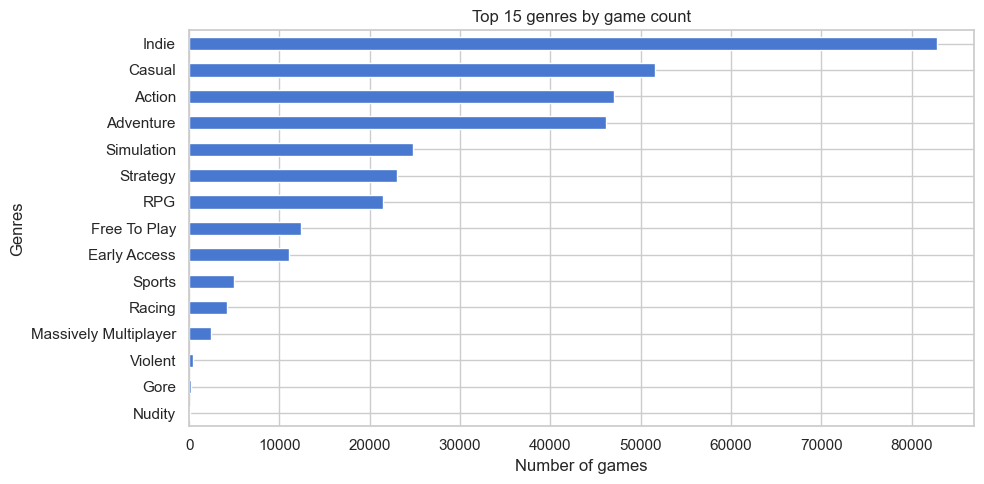

In [14]:
# Explode comma-separated genres into individual rows
genres_flat = (
    df_raw["Genres"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

fig, ax = plt.subplots(figsize=(10, 5))
genres_flat.head(15).sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Number of games")
ax.set_title("Top 15 genres by game count")
plt.tight_layout()
plt.savefig("../outputs/eda_genres.png", dpi=150)
plt.show()

## 6. Review score vs. copiesSold

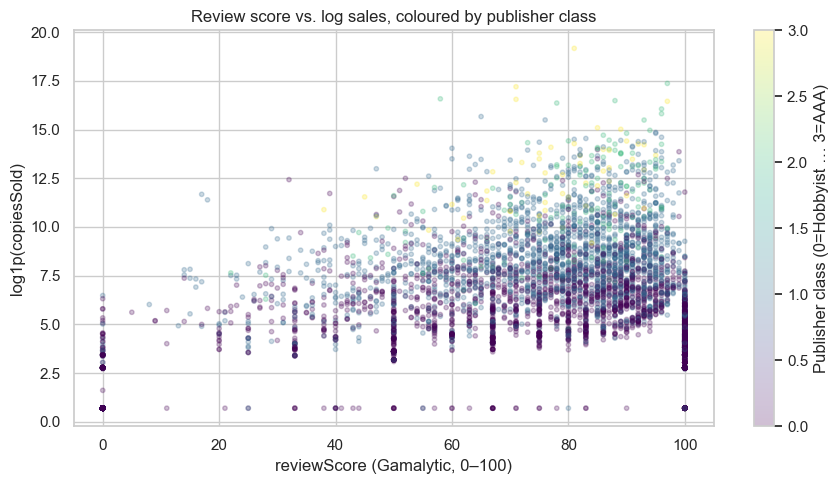

In [15]:
sample = df_raw.dropna(subset=["reviewScore", "copiesSold"]).sample(
    min(5000, len(df_raw)), random_state=42
)

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    sample["reviewScore"],
    np.log1p(sample["copiesSold"]),
    alpha=0.25, s=10,
    c=sample["publisherClass"].map({"Hobbyist": 0, "Indie": 1, "AA": 2, "AAA": 3}),
    cmap="viridis",
)
ax.set_xlabel("reviewScore (Gamalytic, 0–100)")
ax.set_ylabel("log1p(copiesSold)")
ax.set_title("Review score vs. log sales, coloured by publisher class")
plt.colorbar(sc, ax=ax, label="Publisher class (0=Hobbyist … 3=AAA)")
plt.tight_layout()
plt.savefig("../outputs/eda_review_vs_sales.png", dpi=150)
plt.show()

## 7. Release year trend

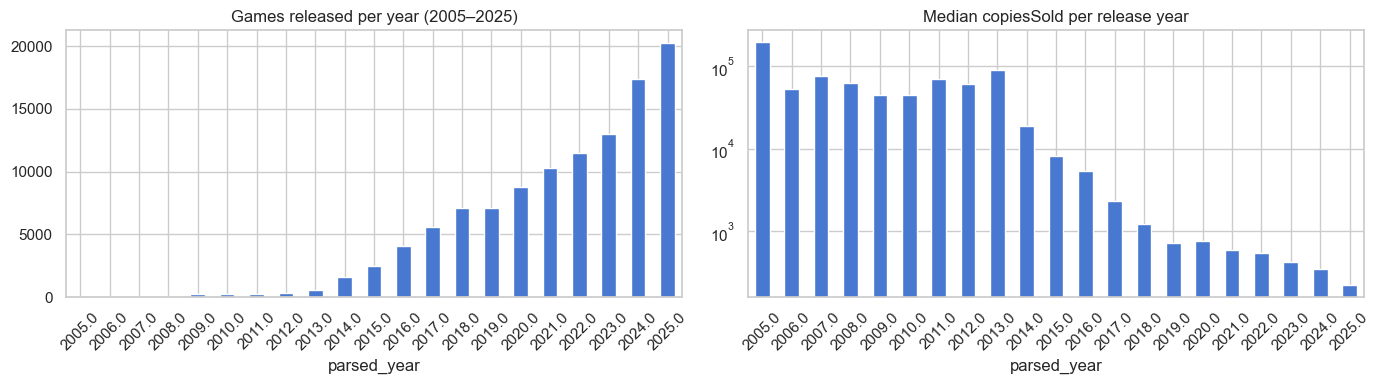

In [19]:
from datetime import datetime

df_raw["parsed_year"] = pd.to_datetime(
    df_raw["firstReleaseDate"], utc=True, errors="coerce"
).dt.year

year_counts  = df_raw["parsed_year"].value_counts().sort_index()
year_med_cs  = df_raw.groupby("parsed_year")["copiesSold"].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
year_counts[(year_counts.index >= 2005) & (year_counts.index <= 2025)].plot(kind="bar", ax=axes[0])
axes[0].set_title("Games released per year (2005–2025)")
axes[0].tick_params(axis="x", rotation=45)

year_med_cs[(year_med_cs.index >= 2005) & (year_med_cs.index <= 2025)].plot(kind="bar", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Median copiesSold per release year")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../outputs/eda_release_year.png", dpi=150)
plt.show()

## 8. Correlation heatmap (numeric columns)

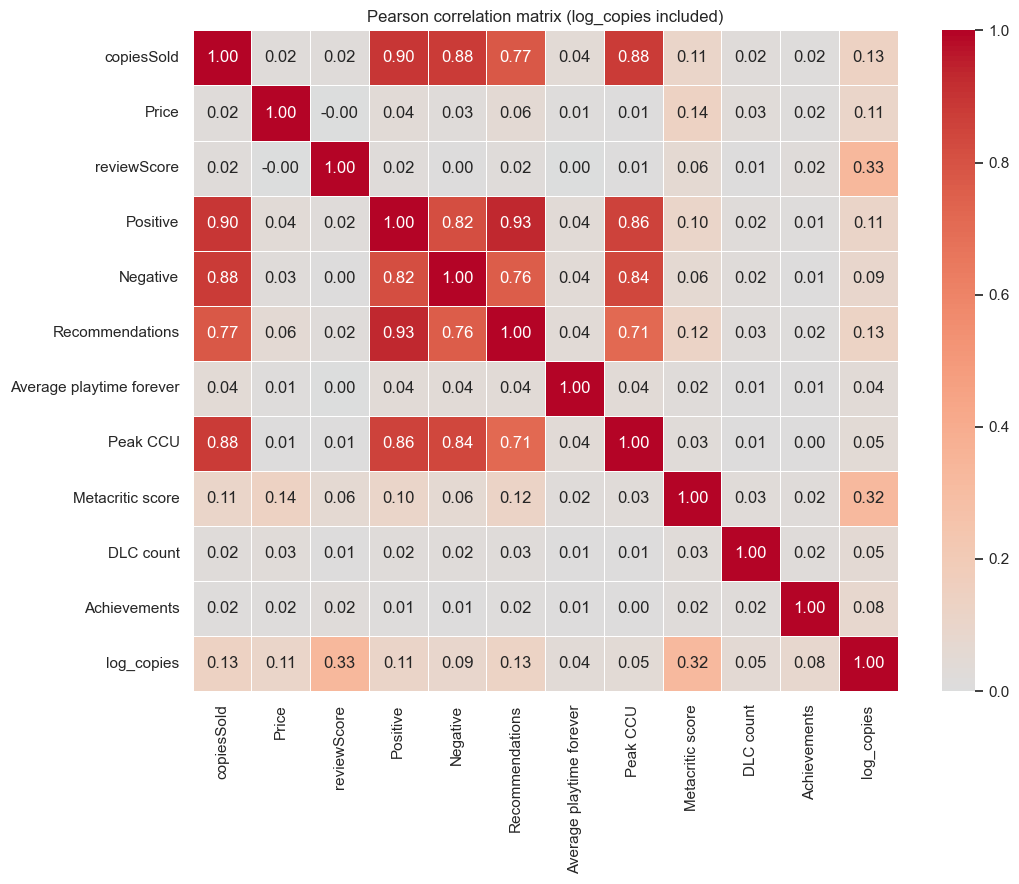

In [20]:
numeric_cols = [
    "copiesSold", "Price", "reviewScore", "Positive", "Negative",
    "Recommendations", "Average playtime forever", "Peak CCU",
    "Metacritic score", "DLC count", "Achievements",
]
corr_df = df_raw[numeric_cols].copy()
corr_df["log_copies"] = np.log1p(corr_df["copiesSold"])

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_df.corr(),
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5, ax=ax,
)
ax.set_title("Pearson correlation matrix (log_copies included)")
plt.tight_layout()
plt.savefig("../outputs/eda_correlation.png", dpi=150)
plt.show()

## 9. Key takeaways

| Observation | Implication |
|---|---|
| `copiesSold` is extremely right-skewed (skewness ≈ 70) | Always model `log1p(copiesSold)` |
| Median sales: AAA >> AA >> Indie >> Hobbyist | `publisherClass` is a strong predictor |
| Free games have ~5× higher median sales than paid | F2P flag is a useful feature; TA cautions estimates are noisier |
| `reviewScore`, `Positive`, `Recommendations` strongly correlated with sales | Post-release leakage risk; note in write-up |
| `Metacritic score` is 0 for 96 % of games | Add `has_metacritic` indicator; don't use raw score directly |
| `Score rank`, `User score`, `Movies` are essentially empty | Drop before modelling |
| `Tags`, `Genres`, `Categories` need parsing | Handled in preprocessor.py |